In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display


# ==========================================
# 2. Visualization Function
# ==========================================
def visualize_cross_aggregated_results(csv_path, models_filter):
    if not os.path.exists(csv_path):
        print(f"Error: The file '{csv_path}' does not exist in the current directory.")
        return

    print(f"Loading data from {csv_path}...")
    df = pd.read_csv(csv_path)

    # Melt the dataframe from wide to long format
    df_long = pd.melt(
        df, 
        id_vars=['Parameter', 'True_Value'], 
        var_name='Metric_Model', 
        value_name='Value'
    )

    # Split 'Metric_Model' into 'Metric' and 'Model'
    # n=1 ensures we only split on the first underscore (e.g., "RB" and "model_shift_mean")
    df_long[['Metric', 'Model']] = df_long['Metric_Model'].str.split('_', n=1, expand=True)

    # Drop rows with NaN values (if some parameters are missing in certain models)
    df_long = df_long.dropna(subset=['Value'])

    # --- NEW: Filter by specified models ---
    if models_filter:
        df_long = df_long[df_long['Model'].isin(models_filter)]
        if df_long.empty:
            print(f"Error: None of the models in {models_filter} were found in the CSV.")
            print("Available models in the CSV are:", df.columns.str.split('_', n=1).str[1].dropna().unique().tolist())
            return
        else:
            print(f"Filtering plots to show: {', '.join(models_filter)}")

    # Set the visual theme for the plots
    sns.set_theme(style="whitegrid")
    
    metrics_to_plot = ['RB', 'MSE', 'CP']
    scenario_name = os.path.basename(csv_path).replace('.csv', '')
    
    for metric in metrics_to_plot:
        subset = df_long[df_long['Metric'] == metric]
        
        if subset.empty:
            continue
            
        plt.figure(figsize=(14, 7))
        
        # Create a strip plot (dot plot)
        ax = sns.stripplot(
            data=subset, 
            x='Parameter', 
            y='Value', 
            hue='Model', 
            dodge=True, 
            marker='o', 
            alpha=0.8,
            size=7
        )
        
        plt.title(f'{metric} Comparison Across Models ({scenario_name})', fontsize=16, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.ylabel(metric, fontsize=12, fontweight='bold')
        plt.xlabel('Parameter', fontsize=12, fontweight='bold')
        
        # Place the legend outside the plot area
        plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
        
        # Add helpful reference lines
        if metric == 'CP':
            plt.axhline(y=95.0, color='red', linestyle='--', alpha=0.6, zorder=0)
            plt.text(len(subset['Parameter'].unique())-0.5, 95.5, '95% Nominal', color='red', ha='right')
        elif metric == 'RB':
            plt.axhline(y=0.0, color='red', linestyle='--', alpha=0.6, zorder=0)
            plt.text(len(subset['Parameter'].unique())-0.5, 0.02, 'Zero Bias', color='red', ha='right')
            
        plt.tight_layout()
        
        # Save the figure to disk
        out_filename = f'Plot_{metric}_{scenario_name}.png'
        # plt.savefig(out_filename, dpi=300, bbox_inches='tight')
        
        # Display the plot inline in the Jupyter Notebook
        plt.show()
        print(f"Saved plot: {out_filename}\n")


In [ ]:
import pandas as pd
from IPython.display import display
import numpy as np

def display_metric_table(df, metric, apply_color=False, keyword=None):
    """
    Filters the dataframe to show only the base columns and selected metric columns.
    Optionally filters metric columns by a keyword substring.
    """

    desired_order = [
        'rho', 
        'theta1', 'theta2', 
        'theta5[1]', 'theta5[2]', 'theta5[3]', 
        'theta7[1]', 'theta7[2]', 'theta7[3]', 
        'lambda[1]', 'lambda[2]', 'lambda[3]', 
        'lambda[4]', 'lambda[5]', 'lambda[6]', 'lambda[7]', 
        'beta[2,1]', 'beta[2,2]', 
        'beta[5,1]', 'beta[5,2]', 
        'sigma_bk[1]', 'sigma_bk[3]', 'sigma_bk[4]', 'sigma_bk[7]', 
        'Gamma[1,1]', 'Gamma[1,2]', 'Gamma[2,1]', 'Gamma[2,2]'
    ]

    base_cols = ['Parameter', 'True_Value']
    
    # 1. metric columns
    metric_cols = [col for col in df.columns if col.startswith(f"{metric}_")]

    if not metric_cols:
        print(f"No columns found for metric: {metric}")
        return

    # 2. apply keyword filter (NEW)
    if keyword is not None:
        metric_cols = [col for col in metric_cols if keyword in col]

    if not metric_cols:
        print(f"No columns found for metric: {metric} with keyword: {keyword}")
        return

    cols_to_display = base_cols + metric_cols
    df_metric = df[cols_to_display].copy()

    # 3. sorting
    df_metric['sort_key'] = df_metric['Parameter'].apply(
        lambda x: desired_order.index(x.strip()) if x.strip() in desired_order else len(desired_order)
    )
    df_metric = df_metric.sort_values(by=['sort_key', 'Parameter']).drop('sort_key', axis=1).reset_index(drop=True)

    # 4. highlighting logic
    def highlight_best(row):
        styles = pd.Series([''] * len(row), index=row.index)

        if metric in ['MSE', 'Rhat']:
            best_col = row.idxmin()
        elif metric == 'ESS':
            best_col = row.idxmax()
        elif metric == 'RB':
            best_col = row.abs().idxmin()
        elif metric == 'CP':
            best_col = (row - 95).abs().idxmin()
        else:
            best_col = row.idxmax()

        if pd.notna(best_col):
            styles[best_col] = 'font-weight: bold'

        return styles

    print(f"\n--- {metric} Comparison Table ---")

    if apply_color:
        try:
            styled_df = (df_metric.style
                .background_gradient(subset=metric_cols, cmap='coolwarm', axis=1)
                .apply(highlight_best, subset=metric_cols, axis=1)
                .format({col: "{:.3f}" for col in metric_cols})
            )
            display(styled_df)
        except AttributeError:
            print("[Note] Jinja2 is not installed. Falling back to unstyled table.")
            display(df_metric)
    else:
        display(df_metric)

In [57]:
# Load your dataframe (if not already loaded in memory)
df = pd.read_csv("../corrected_results/FINAL_COMPARISON_S2_corrected.csv")
# df["Parameter"]

In [58]:
# ==========================================
# Try it out:
# ==========================================

# Display Rhat
display_metric_table(df, 'Rhat')




--- Rhat Comparison Table ---


,Parameter,True_Value,Rhat_model_shift_mean_paper,Rhat_model_shift_mean_full,Rhat_model_shift_mean_cov,Rhat_model_fix_mean,Rhat_model_fix_mean_lap,Rhat_model_shift_mean_cov_lap
0,rho,0.60,1.032,1.006,1.027,1.036,1.025,1.017
1,theta1,2.30,1.002,1.085,1.002,1.003,1.002,1.002
2,theta2,2.60,1.015,1.095,1.015,1.017,1.014,1.015
3,theta5[1],-7.50,1.004,1.080,1.004,1.005,1.003,1.004
4,theta5[2],-2.50,1.003,1.088,1.002,1.006,1.002,1.003
5,theta5[3],2.60,1.003,1.090,1.002,1.002,1.002,1.005
6,theta7[1],-4.30,1.002,1.089,1.002,1.003,1.002,1.002
7,theta7[2],-1.00,1.002,1.088,1.002,1.004,1.001,1.001
8,theta7[3],1.40,1.002,1.087,1.003,1.002,1.002,1.001
9,lambda[1],1.20,1.006,1.002,1.010,1.008,1.004,1.006


In [59]:
# Display Effective Sample Size
display_metric_table(df, 'ESS')




--- ESS Comparison Table ---


,Parameter,True_Value,ESS_model_shift_mean_paper,ESS_model_shift_mean_full,ESS_model_shift_mean_cov,ESS_model_fix_mean,ESS_model_fix_mean_lap,ESS_model_shift_mean_cov_lap
0,rho,0.60,912.1,763.7,913.5,913.7,975.4,957.1
1,theta1,2.30,4633.3,70.0,4640.1,4767.8,4749.8,4702.9
2,theta2,2.60,1838.3,65.8,1909.5,1830.5,1814.4,1823.1
3,theta5[1],-7.50,3246.1,62.4,3286.4,3354.8,3478.5,3383.6
4,theta5[2],-2.50,4788.1,62.2,5262.4,5512.4,5815.6,5408.0
5,theta5[3],2.60,5036.4,62.9,5474.0,5849.0,5980.1,5679.4
6,theta7[1],-4.30,6133.8,63.9,6661.2,7022.9,6981.6,6748.9
7,theta7[2],-1.00,5878.8,62.5,6709.4,7254.8,7510.2,6903.4
8,theta7[3],1.40,5801.6,62.8,6536.1,7100.1,7289.1,6716.5
9,lambda[1],1.20,3864.5,2957.5,3968.2,3919.1,4030.1,4065.4


In [60]:
# Display Coverage Probability
display_metric_table(df, 'CP')


--- CP Comparison Table ---


,Parameter,True_Value,CP_model_shift_mean_paper,CP_model_shift_mean_full,CP_model_shift_mean_cov,CP_model_fix_mean,CP_model_fix_mean_lap,CP_model_shift_mean_cov_lap
0,rho,0.60,93.7,100.0,93.9,94.8,96.4,96.4
1,theta1,2.30,97.1,100.0,97.3,96.0,96.4,96.4
2,theta2,2.60,93.7,100.0,95.3,96.0,95.9,95.4
3,theta5[1],-7.50,92.6,100.0,93.9,94.3,93.9,93.8
4,theta5[2],-2.50,93.1,100.0,95.9,94.8,93.9,94.8
5,theta5[3],2.60,94.9,100.0,94.6,95.4,95.9,94.3
6,theta7[1],-4.30,94.9,100.0,95.9,93.1,93.9,96.4
7,theta7[2],-1.00,90.3,100.0,90.5,93.1,92.3,92.3
8,theta7[3],1.40,93.7,100.0,96.6,94.3,94.4,95.4
9,lambda[1],1.20,97.1,100.0,99.3,95.4,96.9,97.4


In [61]:
# Display Relative Bias
display_metric_table(df, 'RB')


--- RB Comparison Table ---


,Parameter,True_Value,RB_model_shift_mean_paper,RB_model_shift_mean_full,RB_model_shift_mean_cov,RB_model_fix_mean,RB_model_fix_mean_lap,RB_model_shift_mean_cov_lap
0,rho,0.60,0.021,0.042,0.021,0.022,0.015,0.017
1,theta1,2.30,0.025,-0.297,0.021,0.016,0.012,0.014
2,theta2,2.60,0.056,-0.667,0.054,0.053,0.045,0.048
3,theta5[1],-7.50,-0.005,-0.212,-0.006,-0.006,-0.006,-0.008
4,theta5[2],-2.50,0.003,-0.544,-0.004,-0.001,0.001,-0.002
5,theta5[3],2.60,-0.017,0.440,-0.017,-0.016,-0.019,-0.016
6,theta7[1],-4.30,0.007,-0.092,0.007,0.007,0.007,0.006
7,theta7[2],-1.00,0.009,-0.329,0.010,0.005,0.009,0.007
8,theta7[3],1.40,-0.004,0.254,-0.002,0.002,-0.001,-0.001
9,lambda[1],1.20,0.006,-0.052,-0.002,0.004,0.019,0.008


In [62]:
# Display Mean Squared Error
display_metric_table(df, 'MSE')


--- MSE Comparison Table ---


,Parameter,True_Value,MSE_model_shift_mean_paper,MSE_model_shift_mean_full,MSE_model_shift_mean_cov,MSE_model_fix_mean,MSE_model_fix_mean_lap,MSE_model_shift_mean_cov_lap
0,rho,0.60,0.003,0.002,0.003,0.003,0.003,0.003
1,theta1,2.30,0.079,0.562,0.074,0.083,0.082,0.082
2,theta2,2.60,0.232,3.039,0.218,0.224,0.210,0.222
3,theta5[1],-7.50,0.369,2.565,0.337,0.323,0.339,0.348
4,theta5[2],-2.50,0.163,2.035,0.145,0.135,0.143,0.146
5,theta5[3],2.60,0.144,1.783,0.134,0.131,0.131,0.141
6,theta7[1],-4.30,0.036,0.176,0.034,0.035,0.035,0.033
7,theta7[2],-1.00,0.020,0.111,0.020,0.018,0.018,0.018
8,theta7[3],1.40,0.019,0.153,0.016,0.016,0.016,0.017
9,lambda[1],1.20,0.042,0.028,0.038,0.047,0.046,0.045


Loading data from ../corrected_results/FINAL_COMPARISON_S2_corrected.csv...
Filtering plots to show: model_shift_mean_paper, model_fix_mean


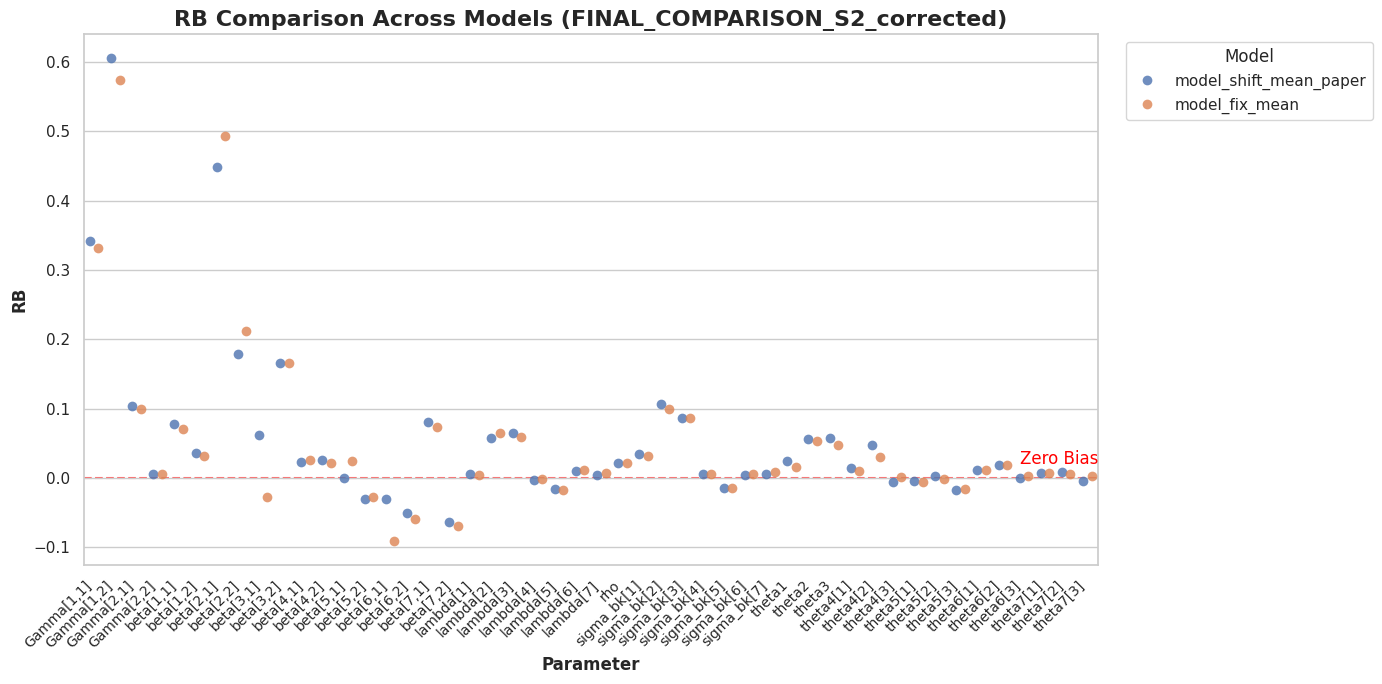

Saved plot: Plot_RB_FINAL_COMPARISON_S2_corrected.png



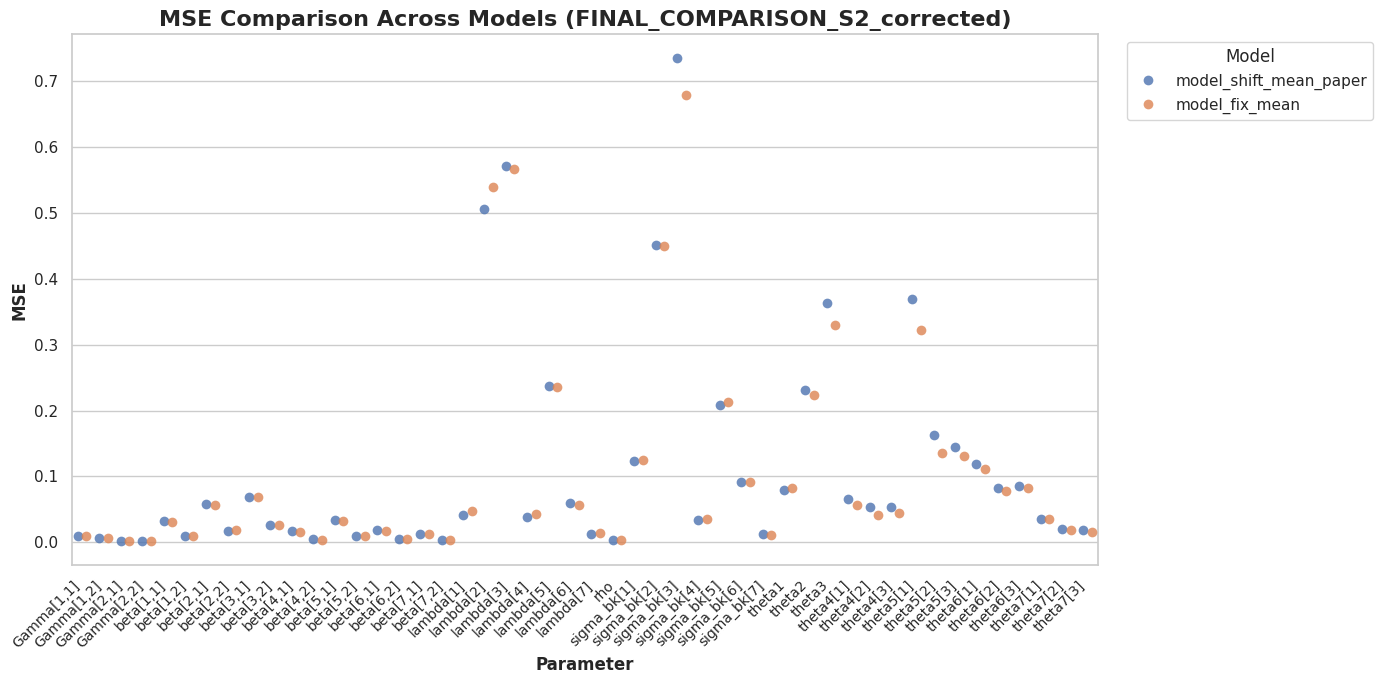

Saved plot: Plot_MSE_FINAL_COMPARISON_S2_corrected.png



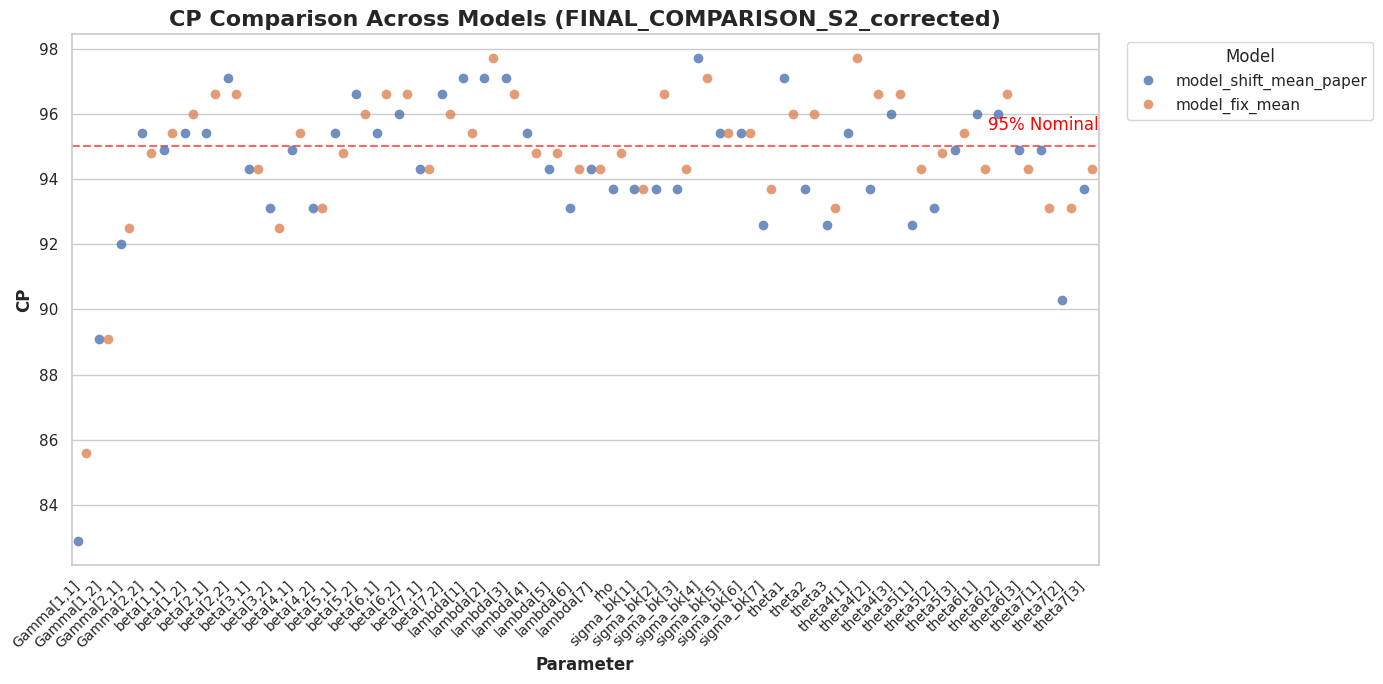

Saved plot: Plot_CP_FINAL_COMPARISON_S2_corrected.png



In [63]:

# ==========================================
# 1. Configuration
# ==========================================
# Change this to the name of the CSV you want to visualize
csv_path = "../corrected_results/FINAL_COMPARISON_S2_corrected.csv"

# List the specific models you want to visualize (must match the names in the CSV exactly).
# Leave this as an empty list [] to plot ALL models found in the CSV.
models_to_include = [
    "model_shift_mean_paper",
    "model_fix_mean"
]


# ==========================================
# 3. Execution
# ==========================================
visualize_cross_aggregated_results(csv_path, models_to_include)

Loading data from ../corrected_results/FINAL_COMPARISON_S2_corrected.csv...
Filtering plots to show: model_shift_mean_cov, model_fix_mean


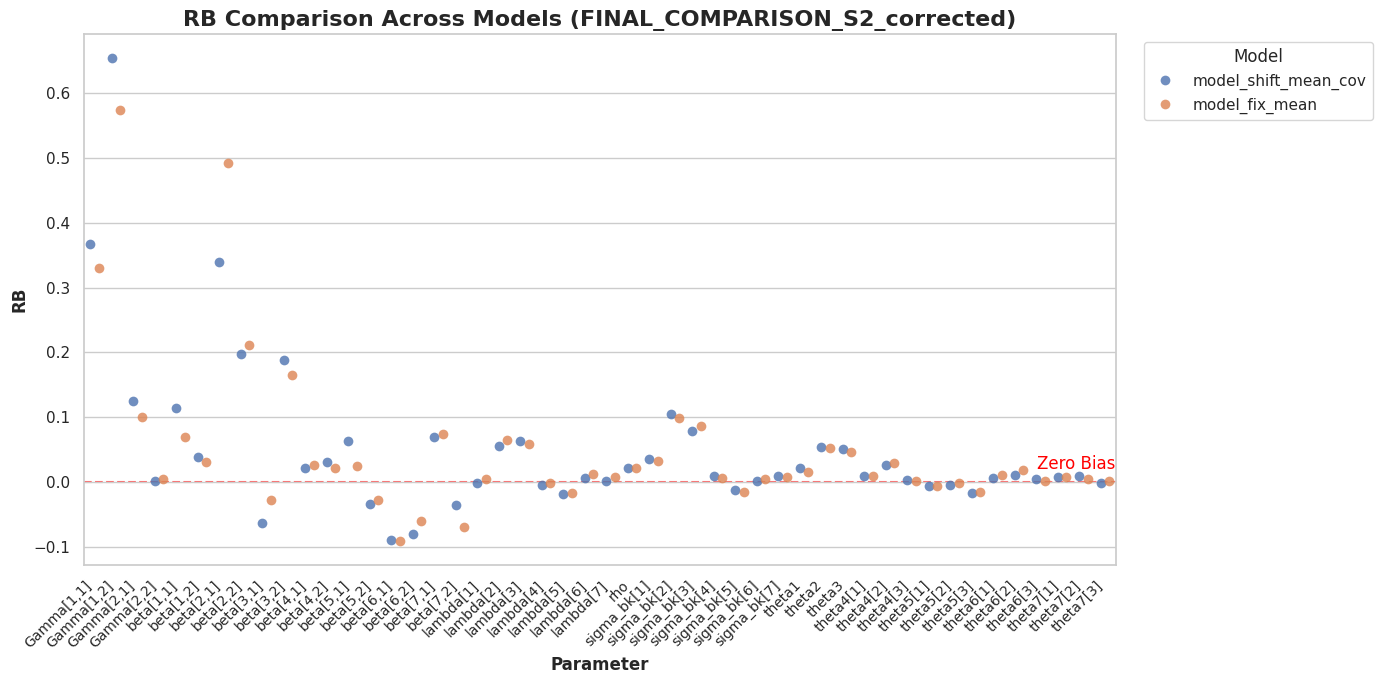

Saved plot: Plot_RB_FINAL_COMPARISON_S2_corrected.png



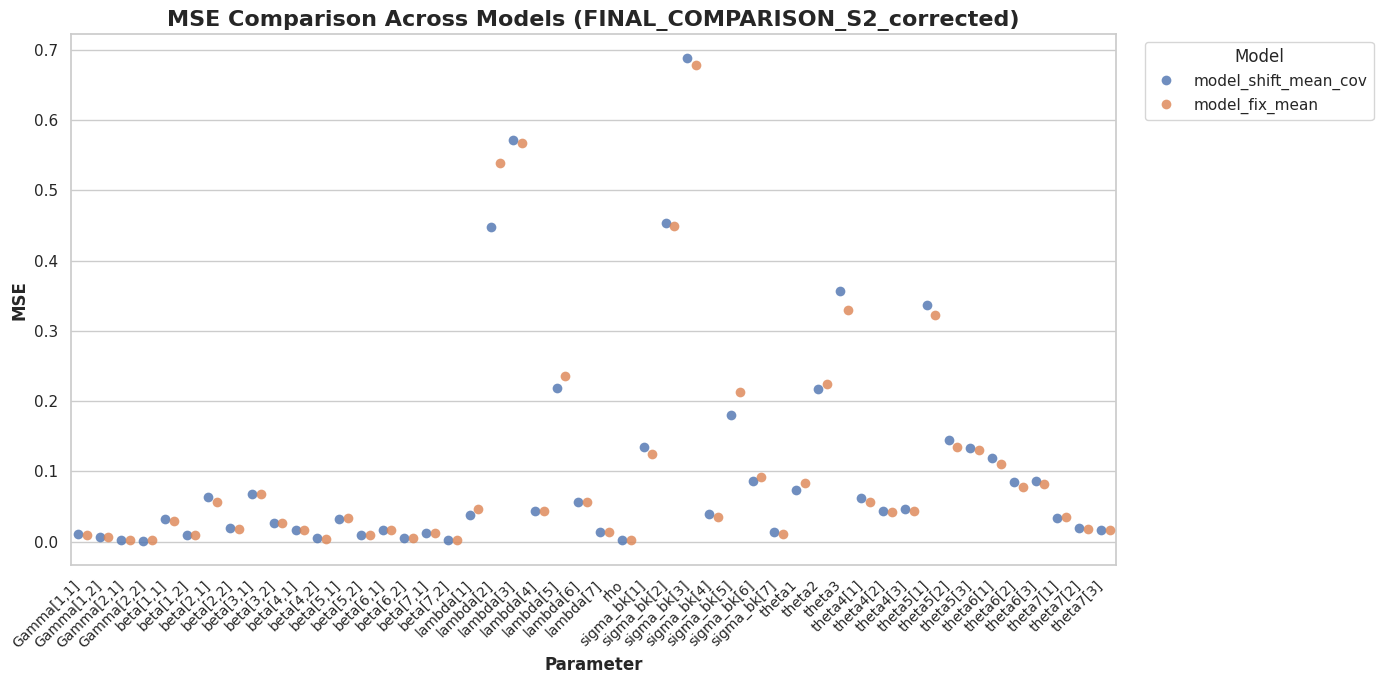

Saved plot: Plot_MSE_FINAL_COMPARISON_S2_corrected.png



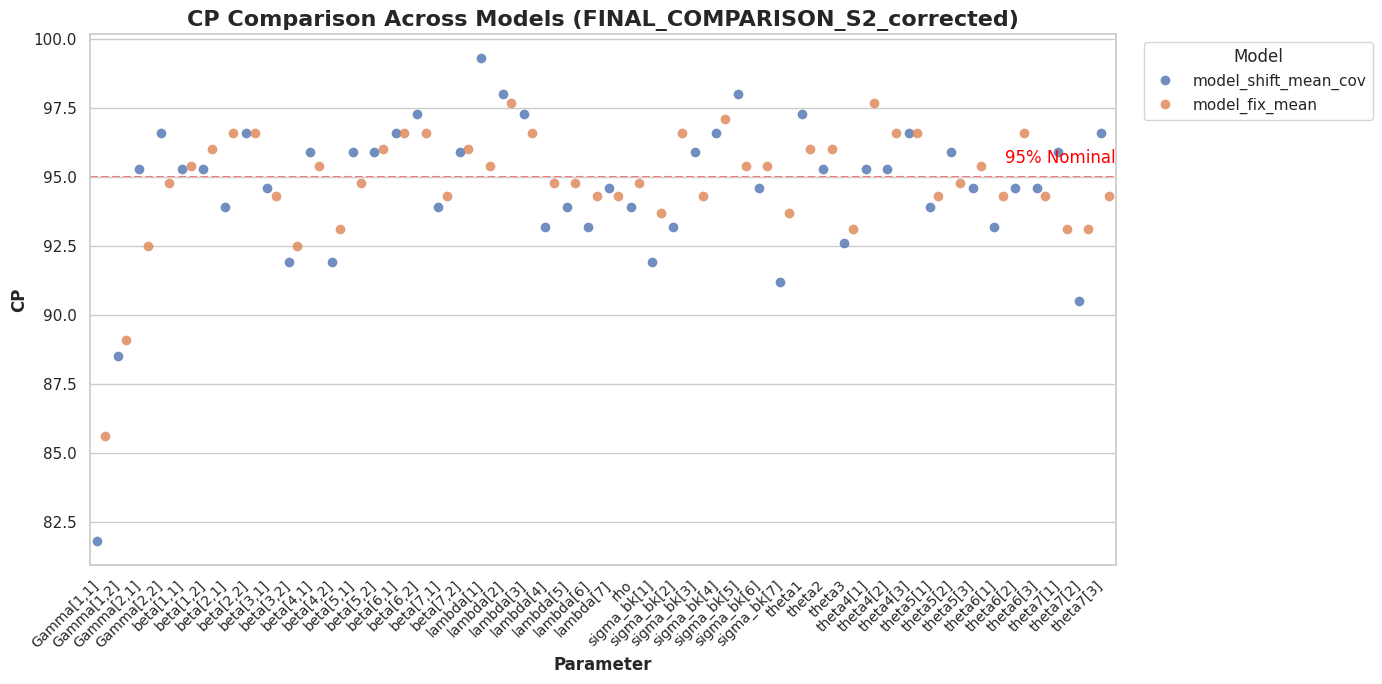

Saved plot: Plot_CP_FINAL_COMPARISON_S2_corrected.png



In [64]:
# List the specific models you want to visualize (must match the names in the CSV exactly).
# Leave this as an empty list [] to plot ALL models found in the CSV.
models_to_include = [
    "model_shift_mean_cov",
    "model_fix_mean"
]


# ==========================================
# 3. Execution
# ==========================================
visualize_cross_aggregated_results(csv_path, models_to_include)

Loading data from ../corrected_results/FINAL_COMPARISON_S2_corrected.csv...
Filtering plots to show: model_fix_mean_lap, model_fix_mean


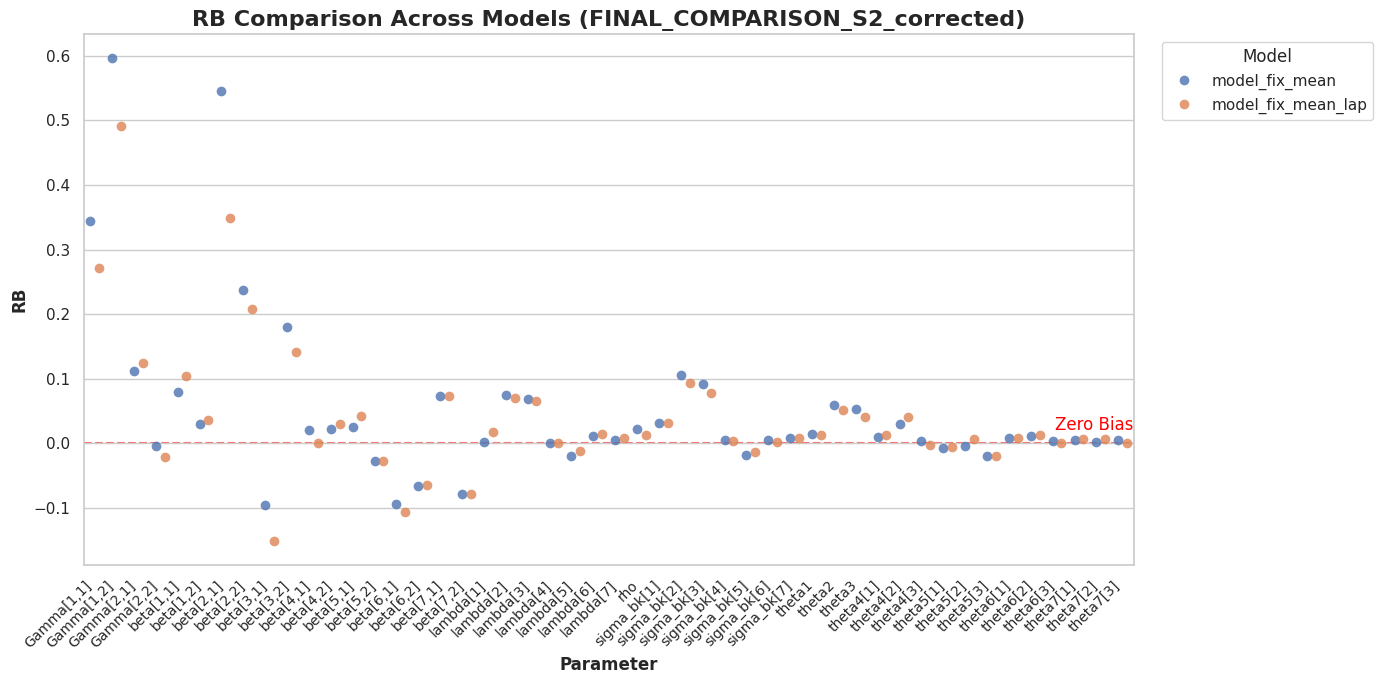

Saved plot: Plot_RB_FINAL_COMPARISON_S2_corrected.png



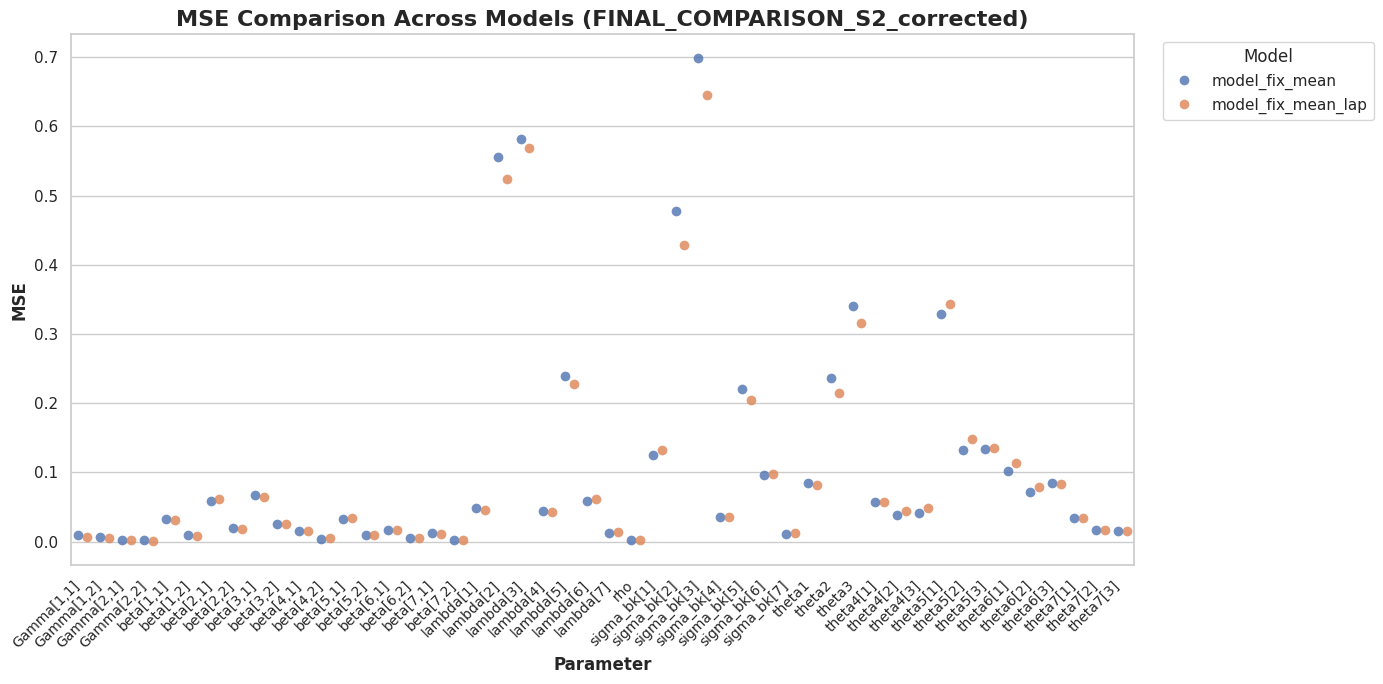

Saved plot: Plot_MSE_FINAL_COMPARISON_S2_corrected.png



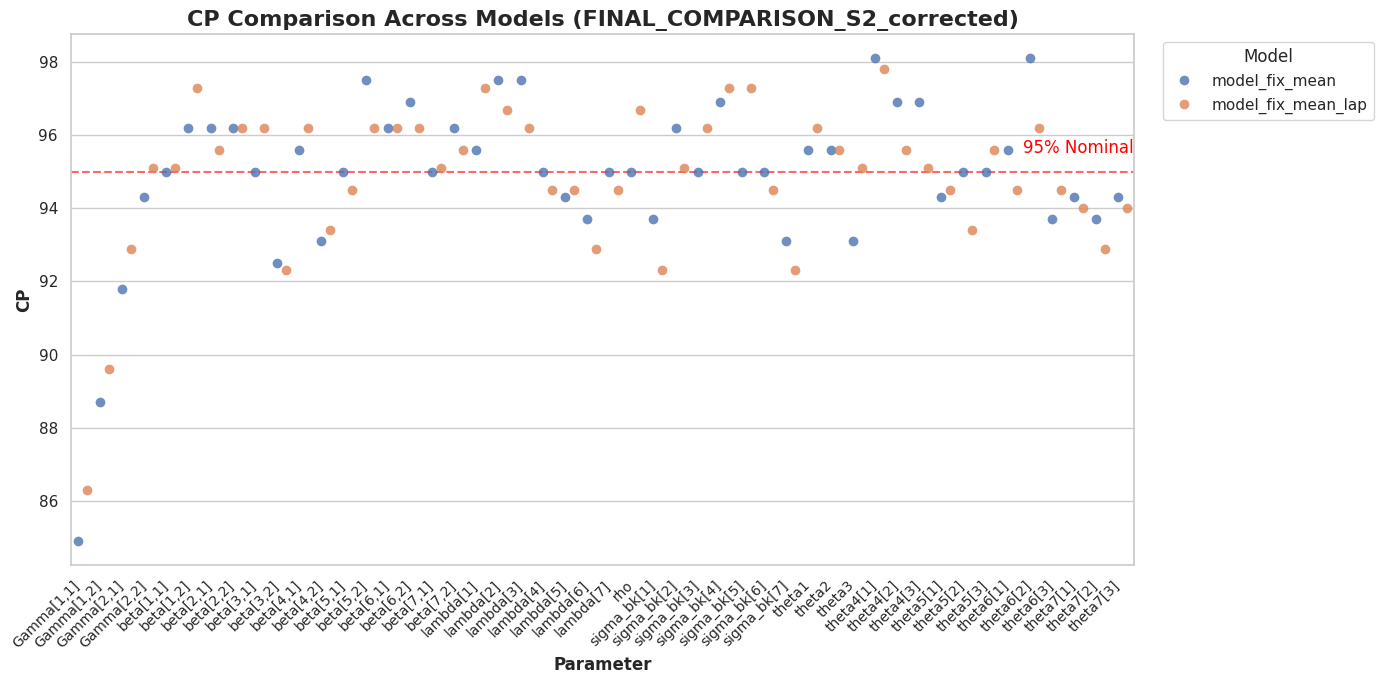

Saved plot: Plot_CP_FINAL_COMPARISON_S2_corrected.png



In [40]:
# List the specific models you want to visualize (must match the names in the CSV exactly).
# Leave this as an empty list [] to plot ALL models found in the CSV.
models_to_include = [
    "model_fix_mean_lap",
    "model_fix_mean"
]


# ==========================================
# 3. Execution
# ==========================================
visualize_cross_aggregated_results(csv_path, models_to_include)

Loading data from ../corrected_results/FINAL_COMPARISON_S2_corrected.csv...
Filtering plots to show: model_shift_mean_cov_lap, model_shift_mean_cov


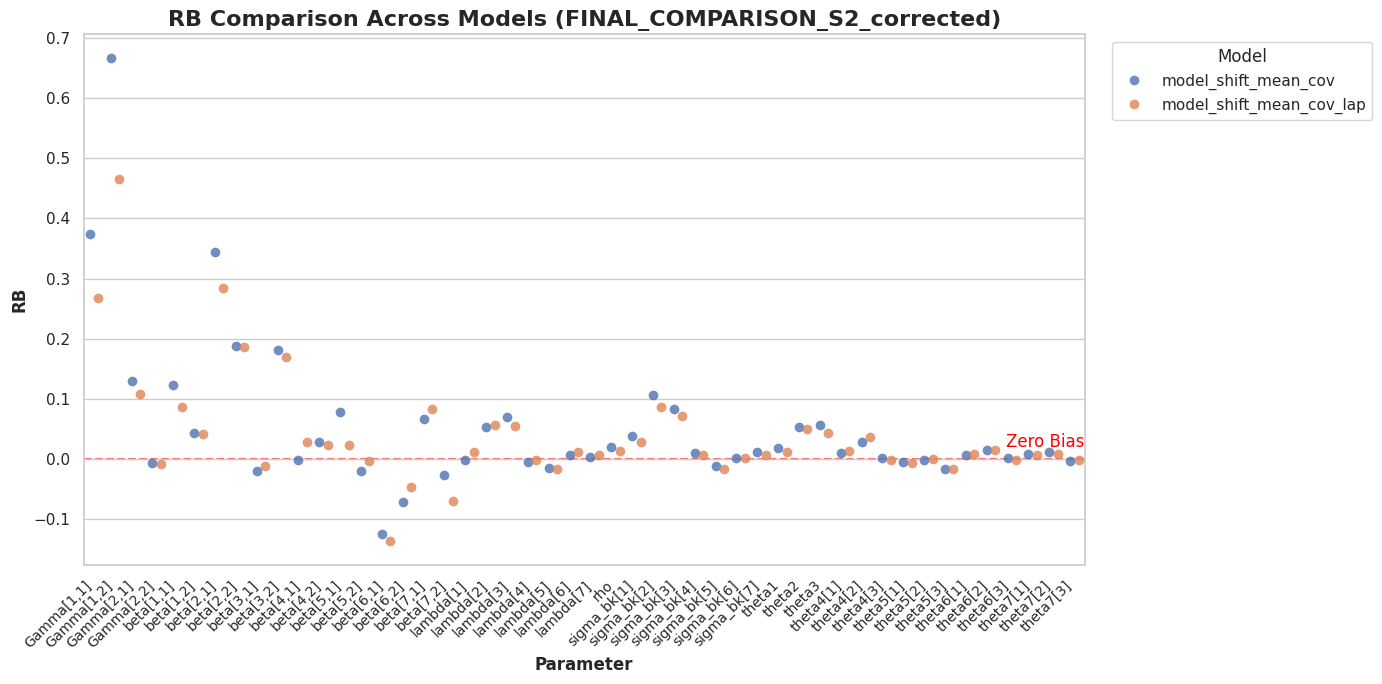

Saved plot: Plot_RB_FINAL_COMPARISON_S2_corrected.png



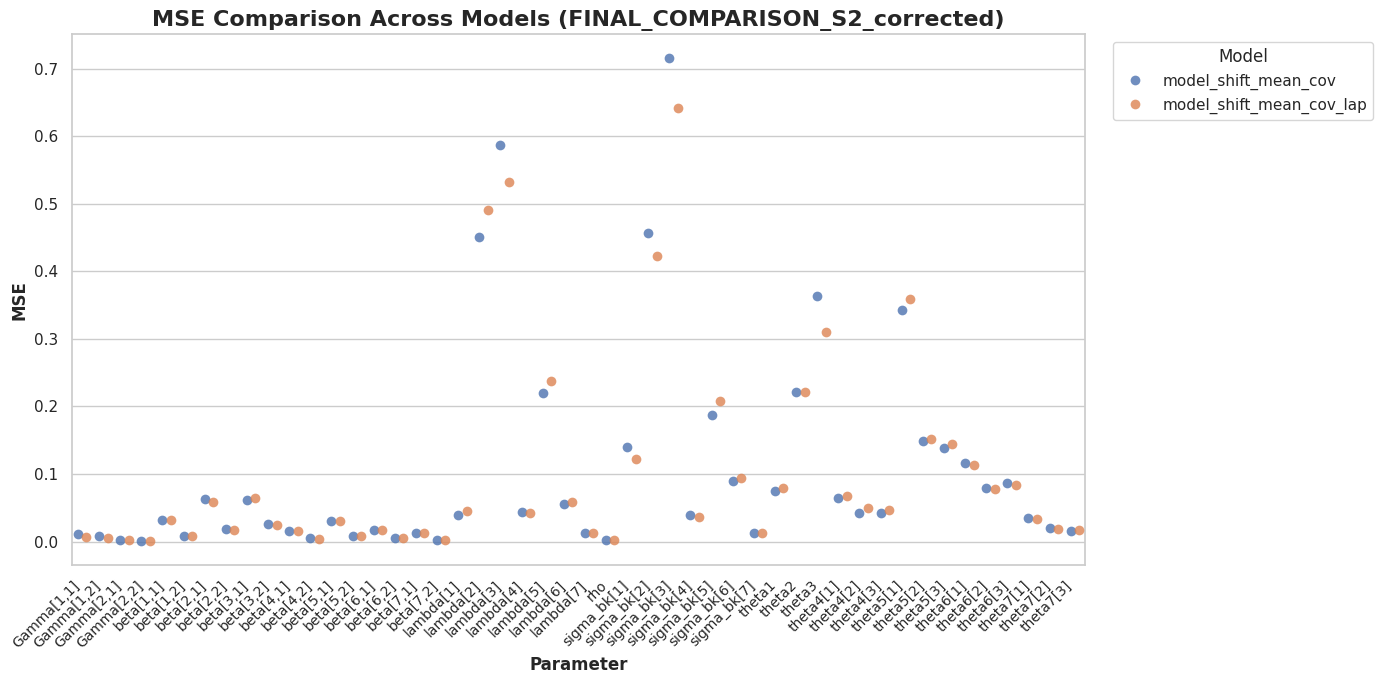

Saved plot: Plot_MSE_FINAL_COMPARISON_S2_corrected.png



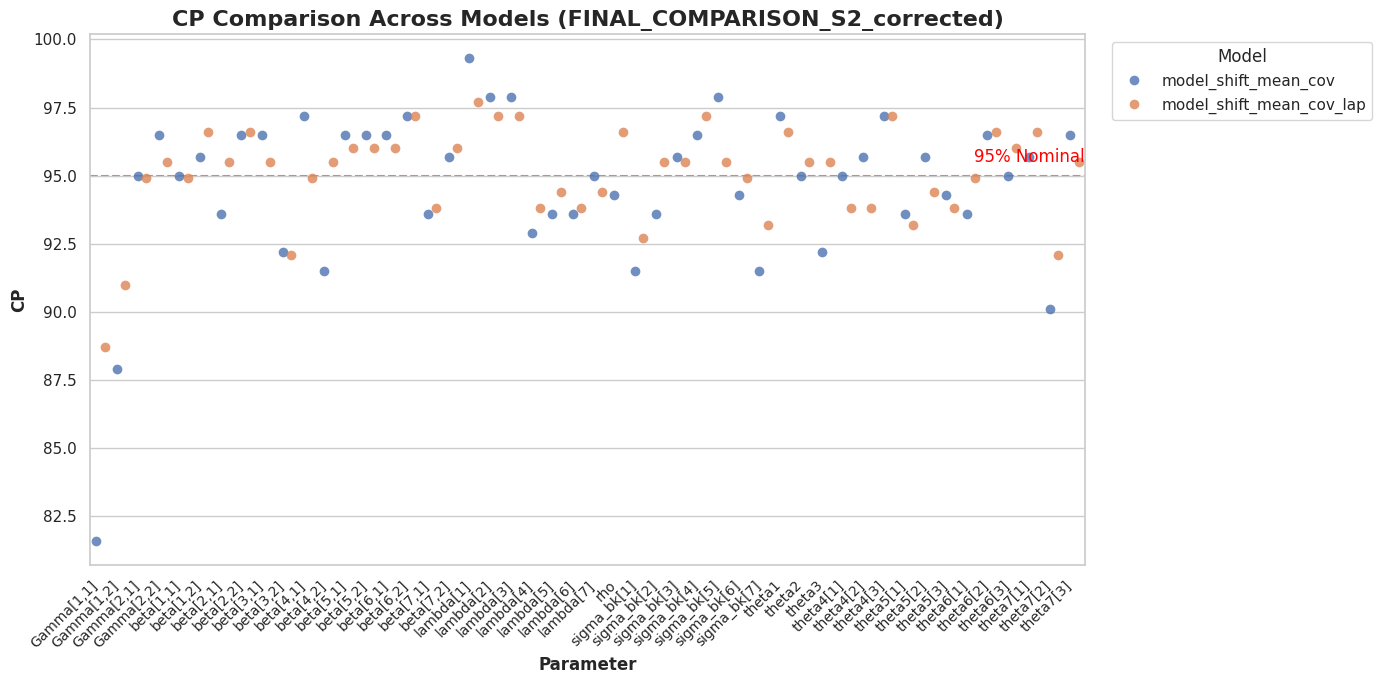

Saved plot: Plot_CP_FINAL_COMPARISON_S2_corrected.png



In [41]:
# List the specific models you want to visualize (must match the names in the CSV exactly).
# Leave this as an empty list [] to plot ALL models found in the CSV.
models_to_include = [
    "model_shift_mean_cov_lap",
    "model_shift_mean_cov"
]


# ==========================================
# 3. Execution
# ==========================================
visualize_cross_aggregated_results(csv_path, models_to_include)

In [70]:
df = pd.read_csv("../corrected_results/results_S2_model_fix_mean_run89.csv")
display(df)

,Run_ID,Parameter,True_Value,Estimate,2.5%,97.5%,R_hat,ESS,Rbias,MSE,Coverage
0,89,theta1,2.30,2.076210,1.672680,2.567210,1.00478,404.54300,-0.097300,0.050082,1
1,89,theta2,2.60,2.116920,1.500120,2.966120,1.10260,24.10990,-0.185800,0.233366,1
2,89,theta3,2.90,3.201560,2.208200,6.404890,1.06954,42.46270,0.103986,0.090938,1
3,89,theta4[1],-4.00,-4.372520,-4.866310,-3.910340,1.02321,268.43800,0.093130,0.138771,1
4,89,theta4[2],-1.00,-1.570900,-1.961570,-1.226250,1.02350,337.45600,0.570900,0.325927,0
5,89,theta4[3],2.70,2.145670,1.755420,2.577860,1.02061,245.97700,-0.205307,0.307282,0
6,89,theta5[1],-7.50,-7.887340,-9.475780,-6.648120,1.01471,173.95100,0.051645,0.150032,1
7,89,theta5[2],-2.50,-3.086000,-4.014810,-2.292250,1.00763,198.64700,0.234400,0.343396,1
8,89,theta5[3],2.60,1.983330,1.247080,2.767600,1.00913,181.26000,-0.237181,0.380282,1
9,89,theta6[1],-5.50,-5.666580,-6.301480,-5.011150,1.01608,156.59400,0.030287,0.027749,1
